# 🔬 Análisis de Datos Magnetotelúricos
---
**Curso:** Magnetotelúrica desde Cero: Fundamentos, Procesamiento e Interpretación de Datos  
**Módulo 3 — Análisis e Interpretación de Datos MT**

Este notebook cubre el análisis de los datos MT procesados:
1. **Profundidad de investigación** (penetration depth).
2. **Tensor de impedancia:** estructura, componentes y dimensionalidad.
3. **Tensor de fase:** mapas para análisis de dimensionalidad 1D/2D/3D.
4. **Strike geoeléctrico:** dirección preferida de las estructuras geológicas.

> **Prerequisito:** haber ejecutado los Notebooks Visualización y Preprocesamiento.

<div style="background:#f4f0fb;border:1px solid #8E44AD;border-radius:6px;padding:12px 16px;margin:10px 0"><b>🧠 El Tensor de Impedancia Z</b><br>La relación entre los campos eléctrico y magnético en MT se expresa mediante el tensor de impedancia 2×2: <b>E = Z · H</b>, donde:<br>• <b>Zxy</b> y <b>Zyx</b> son las componentes <i>anti-diagonales</i> (contienen la mayor parte de la señal en medios 1D/2D).<br>• <b>Zxx</b> y <b>Zyy</b> son las componentes <i>diagonales</i> (cero para un medio 1D, no cero en medios 2D/3D).<br>De Z se derivan la <b>resistividad aparente</b> y la <b>fase</b>, que son los datos que se invierten.</div>

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 1 · Importar librerías</span></div>

In [1]:
# Importar librerías
from pathlib import Path
from mtpy import MT, MTData, MTCollection
import h5py
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 2 · Cargar datos procesados</span></div>

In [2]:
# Convertir a MTData
with MTCollection() as mc:
    mc.open_collection(Path("h5_procesado\collection_procesado_interpolado.h5")) # Ruta del h5 procesado
    mtd = mc.to_mt_data()

26:03:17T15:28:52 | INFO | line:777 |mth5.mth5 | close_mth5 | Flushing and closing h5_procesado\collection_procesado_interpolado.h5


<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 3 · Profundidad de investigación</span></div>

<div style="background:#f0f9ef;border-left:5px solid #27AE60;padding:10px 14px;border-radius:4px;margin:6px 0">La <b>profundidad de penetración</b> (skin depth) estima hasta qué profundidad penetra la señal EM a una frecuencia dada: <b>δ ≈ 503 √(ρ·T)</b> metros, donde ρ es la resistividad aparente y T el periodo. Para un sondeo real, MTpy calcula la profundidad de investigación usando el método de <b>Niblett-Bostick</b>, que aplica una transformación 1D a las curvas ρ<sub>a</sub> y φ para obtener una estimación continua de la profundidad en función del periodo.</div>

Se grafica la profundidad de investigación de un sondeo específico.

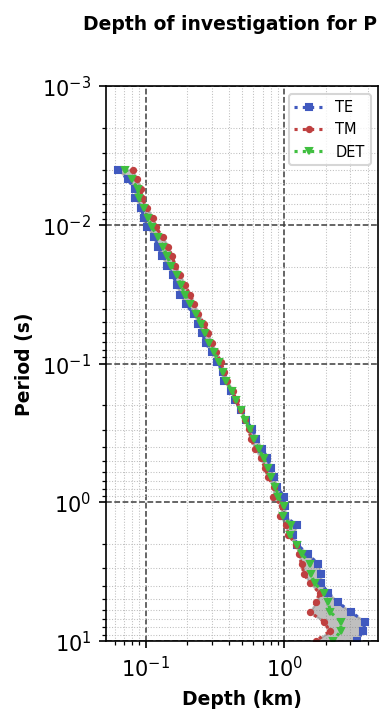

Plotting PlotPenetrationDepth1D

In [3]:
stationn="edi.P"  # Cambiar el nombre de la estación
mtd.plot_penetration_depth_1d(station_key=stationn)

In [4]:
mc.close_collection() # cerrar MTCollection una vez creado el MTData para evitar daños

26:03:17T15:28:54 | WARNING | line:330 |mth5.mth5 | filename | MTH5 file is not open or has not been created yet. Returning default name
26:03:17T15:28:54 | INFO | line:777 |mth5.mth5 | close_mth5 | Flushing and closing h5_procesado\collection_procesado_interpolado.h5


<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 4 · Análisis del tensor de impedancia</span></div>

### Cargar un sondeo directamente desde su EDI
Para el análisis detallado de un sondeo individual, es más conveniente
cargar su EDI directamente con `MT()` que navegar el MTCollection. Aquí se obtiene información acerca de la impedancia de los datos incluyendo su dimensionalidad.

In [5]:
# Cargar un sondeo desde su EDI procesado
mt_object = MT('Edi_procesado/P_procesado.edi') # Crea un objeto MT de cada edi
mt_object.read() # Lee el objeto

In [6]:
# Inspeccionar el objeto Impedancia (Z)
# Contiene los tensores complejos, sus errores y métodos de análisis
i = mt_object.Z
i

Transfer Function impedance
------------------------------
	Number of periods:  50
	Frequency range:        1.00000E-01 -- 2.51189E+02 Hz
	Period range:           3.98107E-03 -- 1.00000E+01 s

	Has impedance:              True
	Has impedance_error:        True
	Has impedance_model_error:  False

In [7]:
# Ver cuántos períodos tiene la estación y cuáles son
print(len(mt_object.Z.period))
print(mt_object.Z.period)

50
[3.98107239e-03 4.67076261e-03 5.47993549e-03 6.42929289e-03
 7.54312214e-03 8.84990995e-03 1.03830882e-02 1.21818794e-02
 1.42922969e-02 1.67683303e-02 1.96733167e-02 2.30815696e-02
 2.70802727e-02 3.17717315e-02 3.72759344e-02 4.37337037e-02
 5.13102324e-02 6.01993683e-02 7.06284520e-02 8.28642526e-02
 9.72198997e-02 1.14062491e-01 1.33822947e-01 1.57006773e-01
 1.84207012e-01 2.16119441e-01 2.53560496e-01 2.97487923e-01
 3.49025521e-01 4.09491522e-01 4.80432697e-01 5.63664178e-01
 6.61314866e-01 7.75882469e-01 9.10298296e-01 1.06800044e+00
 1.25302339e+00 1.47010029e+00 1.72478383e+00 2.02358980e+00
 2.37416115e+00 2.78546644e+00 3.26802726e+00 3.83418823e+00
 4.49843365e+00 5.27775227e+00 6.19208082e+00 7.26481259e+00
 8.52339074e+00 1.00000000e+01]


In [8]:
# Extraer el tensor de impedancia complejo
Z = mt_object.Z.z
periods = mt_object.Z.period

# Organizar las componentes del tensor en una tabla
df = pd.DataFrame({
    "period_s": periods,
    "Zxx": Z[:, 0, 0],
    "Zxy": Z[:, 0, 1],
    "Zyx": Z[:, 1, 0],
    "Zyy": Z[:, 1, 1],
})
print(df.to_string(index=False))

 period_s                 Zxx                  Zxy                   Zyx                 Zyy
 0.003981 -2.721226-7.148531j 70.747840+71.188310j -86.200640-93.505640j  1.775519-0.272238j
 0.004671 -2.574185-0.171902j 65.127150+75.516440j -78.153680-86.517950j  3.344705-0.506173j
 0.005480 -0.976019-0.170281j 61.002450+73.948410j -72.280730-77.176210j  4.240895-1.311812j
 0.006429 -1.088588+2.539616j 50.657870+64.939490j -62.176620-67.796130j  4.453703-2.451328j
 0.007543 -3.099878+1.206631j 47.600300+61.574170j -57.749360-63.565900j  3.963016-1.857292j
 0.008850 -5.788630-0.401918j 43.237440+53.504730j -53.721500-59.246140j  3.691998-2.076473j
 0.010383 -1.760925+2.131996j 38.746530+48.726770j -48.290570-53.213460j  1.882321-3.450775j
 0.012182 -1.382320+0.623478j 36.157370+46.947430j -45.820420-50.904910j  1.371851-3.019507j
 0.014292 -0.146124+1.616977j 32.898210+43.041050j -43.084190-47.477470j  2.881651-1.779438j
 0.016768 -0.569252+2.529877j 29.278720+39.459050j -38.982480-43.10401

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 5 · Análisis de la dimensionalidad del tensor</span></div>

<div style="background:#f0f9ef;border-left:5px solid #27AE60;padding:10px 14px;border-radius:4px;margin:6px 0">La dimensionalidad</b> indica si la Tierra bajo un sondeo se comporta como:<br>• <b>1D</b> (isótropo horizontal): Zxx≈Zyy≈0, Zxy≈−Zyx. Las curvas ρ<sub>a</sub> de los modos TE y TM coinciden.<br>• <b>2D</b>: hay una dirección de strike preferida; TE y TM divergen al alejarse de esa dirección.<br>• <b>3D</b>: el subsuelo tiene variaciones en las tres dimensiones; las cuatro componentes del tensor son significativas.</div>

In [9]:
# Estimar la dimensionalidad del sondeo en cada período
dimensionality = mt_object.Z.estimate_dimensionality()

# Crear DataFrame resumen
df_dim = pd.DataFrame({
    "Periodo (s)"     : periods,
    "Dimensionalidad" : dimensionality,
})

print("Dimensionalidad estimada por periodo:")
print(df_dim.to_string(index=False))

# Resumen estadístico
from collections import Counter
counts = Counter(dimensionality)
print("\nDistribución:")
for dim, cnt in sorted(counts.items()):
    pct = 100 * cnt / len(dimensionality)
    print(f"   {dim}D : {cnt} periodos  ({pct:.1f}%)")

Dimensionalidad estimada por periodo:
 Periodo (s)  Dimensionalidad
    0.003981                1
    0.004671                1
    0.005480                1
    0.006429                2
    0.007543                2
    0.008850                2
    0.010383                2
    0.012182                2
    0.014292                2
    0.016768                2
    0.019673                2
    0.023082                2
    0.027080                2
    0.031772                2
    0.037276                2
    0.043734                2
    0.051310                1
    0.060199                1
    0.070628                2
    0.082864                2
    0.097220                2
    0.114062                2
    0.133823                1
    0.157007                1
    0.184207                2
    0.216119                2
    0.253560                2
    0.297488                2
    0.349026                2
    0.409492                2
    0.480433                2
  

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 7 · Mapa de estaciones</span></div>

<div style="background:#f0f9ef;border-left:5px solid #27AE60;padding:10px 14px;border-radius:4px;margin:6px 0">Para graficar sondeos en un mapa con coordenadas cartesianas (este, norte) en metros, MTpy necesita saber el <b>CRS (Coordinate Reference System)</b> del área de estudio. Se especifica como un código <b>EPSG</b>. Por ejemplo, Colombia Zona 1 = EPSG:9377. Puedes buscar el código de tu zona en <a href='https://epsg.io'>epsg.io</a>.</div>

In [10]:
# Se define el datum de la zona
mtd.utm_crs = 9377
mtd.utm_crs

<Projected CRS: EPSG:9377>
Name: MAGNA-SIRGAS 2018 / Origen-Nacional
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Colombia - onshore and offshore. Includes San Andres y Providencia, Malpelo Islands, Roncador Bank, Serrana Bank and Serranilla Bank.
- bounds: (-84.77, -4.23, -66.87, 15.51)
Coordinate Operation:
- name: Colombia Transverse Mercator
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia 2018
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

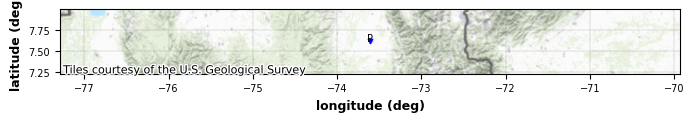

In [11]:
# Graficar el mapa de estaciones
plt.figure(figsize=(8, 12))

mtd.plot_stations(marker_size=10, label_fontsize= 50)

plt.show()

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 8 · Análisis del tensor de fase</span></div>

<div style="background:#f0f9ef;border-left:5px solid #27AE60;padding:10px 14px;border-radius:4px;margin:6px 0">El <b>tensor de fase</b> (Caldwell et al., 2004) es una representación de la respuesta MT libre de distorsión galvánica. Se visualiza como elipses en un mapa donde:<br>• La <b>orientación</b> del eje mayor indica la dirección de strike.<br>• La <b>excentricidad</b> (relación ejes) refleja la dimensionalidad: elipses circulares → 1D; muy elípticas → 2D/3D.<br>• El <b>color</b> representa β (fase invariante), un indicador de simetría: β≈0 → estructura 1D; |β|>3° → efectos 2D y 3D significativos.<br>Las <b>flechas de Tipper</b> apuntan hacia conductores.</div>

Los mapas de tensor de fase son un indicativo de la dimensionalidad del área a diferentes periodos.

26:03:17T15:29:03 | WARNING | line:794 |mtpy.imaging.plot_phase_tensor_maps | plot | Could not add base map because Tile URL resulted in a 404 error. Double-check your tile url:
https://basemap.nationalmap.gov/arcgis/rest/services/USGSTopo/MapServer/tile/16/31376/19365


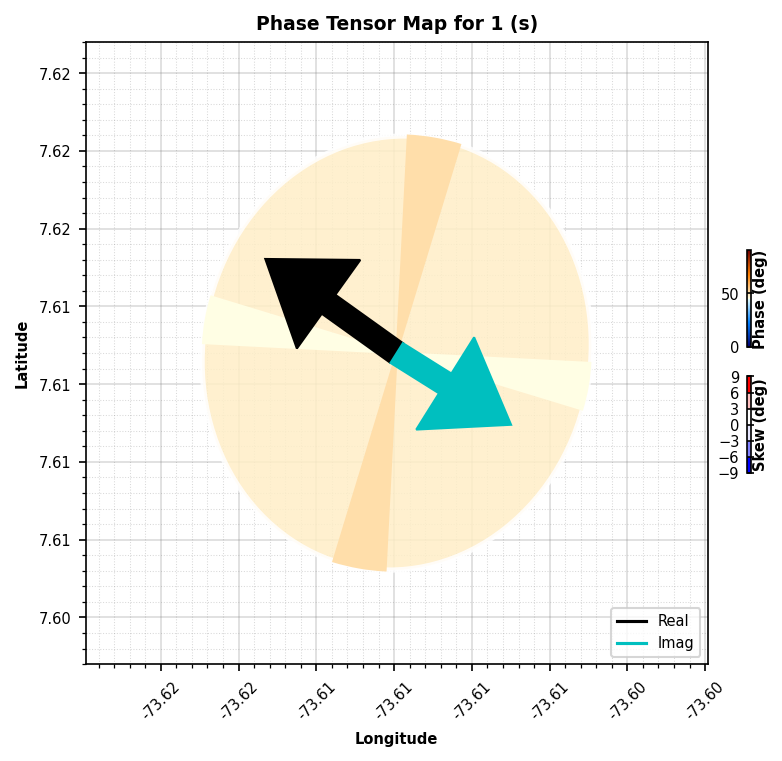

In [12]:
pt_map = mtd.plot_phase_tensor_map(
    plot_tipper="yri", 
    ellipse_size=.007,
    arrow_size=.007
)

### Mapa de tensor de fase a 0.1 segundos

26:03:17T15:29:05 | WARNING | line:794 |mtpy.imaging.plot_phase_tensor_maps | plot | Could not add base map because Tile URL resulted in a 404 error. Double-check your tile url:
https://basemap.nationalmap.gov/arcgis/rest/services/USGSTopo/MapServer/tile/16/31376/19365


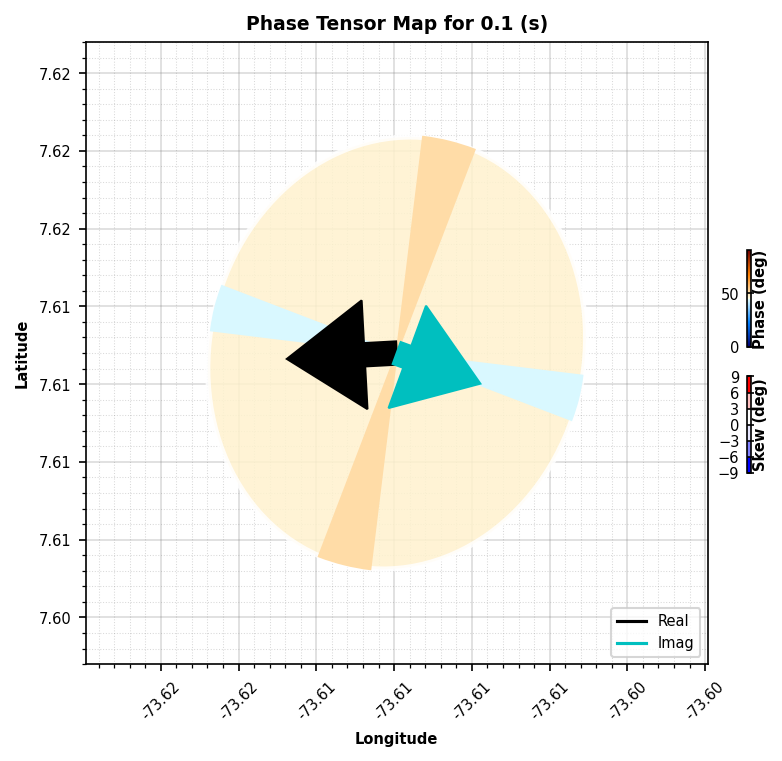

In [13]:
pt_map.plot_period = 0.1 # especificar el periodo que se quiere visualizar
pt_map.redraw_plot()

### Mapa de tensor de fase a 0.1 segundos

26:03:17T15:29:06 | WARNING | line:794 |mtpy.imaging.plot_phase_tensor_maps | plot | Could not add base map because Tile URL resulted in a 404 error. Double-check your tile url:
https://basemap.nationalmap.gov/arcgis/rest/services/USGSTopo/MapServer/tile/16/31376/19365


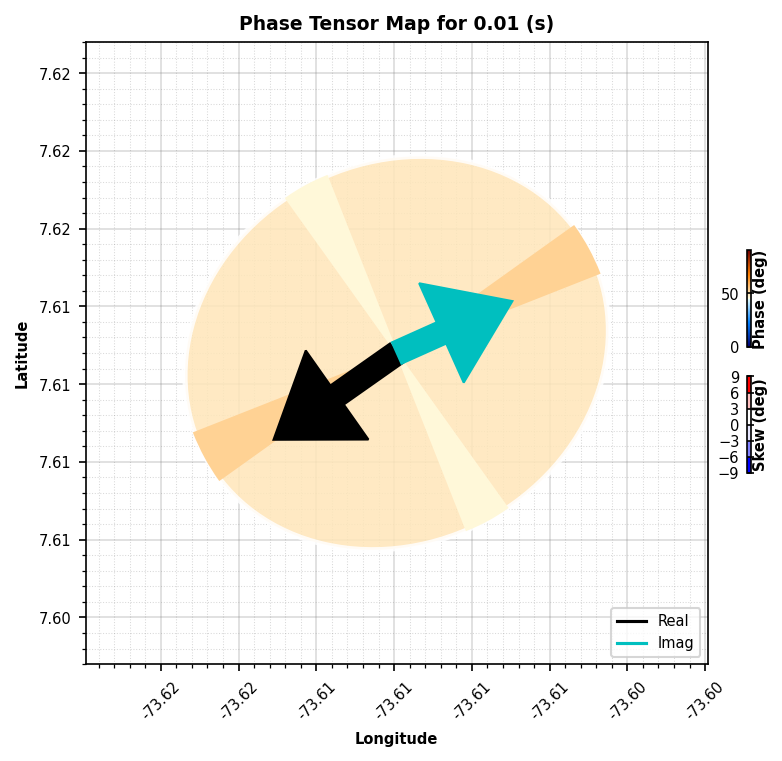

In [14]:
pt_map.plot_period = 0.01
pt_map.redraw_plot()

## Componentes del tensor de fase 

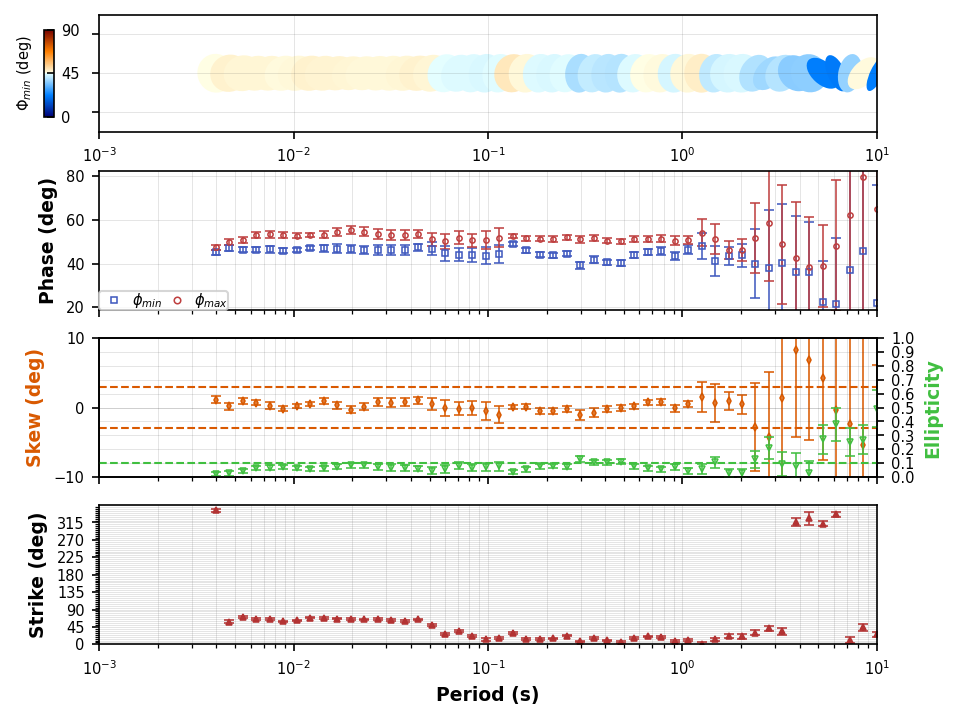

In [15]:
# Graficar las componentes del tensor de fase
try:
    mtd.plot_phase_tensor("edi.P")
except:
    pass

In [16]:
mc.close_collection() # una vez graficado el perfil cerramos la colección para evitar daños

26:03:17T15:29:10 | WARNING | line:330 |mth5.mth5 | filename | MTH5 file is not open or has not been created yet. Returning default name
26:03:17T15:29:10 | INFO | line:777 |mth5.mth5 | close_mth5 | Flushing and closing h5_procesado\collection_procesado_interpolado.h5


<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 9 · Análisis de direccionalidad (Strike geoeléctrico)</span></div>

<div style="background:#f0f9ef;border-left:5px solid #27AE60;padding:10px 14px;border-radius:4px;margin:6px 0">El <b>strike geoeléctrico</b> es la dirección azimutal de la elongación de las estructuras geológicas que controlan la respuesta MT. El strike tiene una <b>ambigüedad de 90°</b> (no distingue entre el rumbo y su perpendicular), resuelta a veces por el Tipper o el conocimiento geológico. Es la rotación que separa los modos TE y TM para modelado 2D.</div>

### Strike geoeléctrico para todos los periodos

La dirección geoeléctrica indica la dirección preferida del flujo de corriente eléctrica. La dirección se vuelve importante cuando se desea determinar cuáles son los modos del tensor de impedancia, es decir, los modos TE y TM. El modo TE es paralelo a la dirección geoeléctrica y el modo TM es perpendicular. Al modelar en 1D y 2D, es importante orientar los modos correctamente. El modelado en 3D elimina esta dependencia, ya que se pueden modelar los cuatro componentes.

26:03:17T15:29:11 | INFO | line:861 |mtpy.imaging.plot_strike | _plot_all_periods | Note: North is assumed to be 0 and the strike angle is measured clockwise positive.


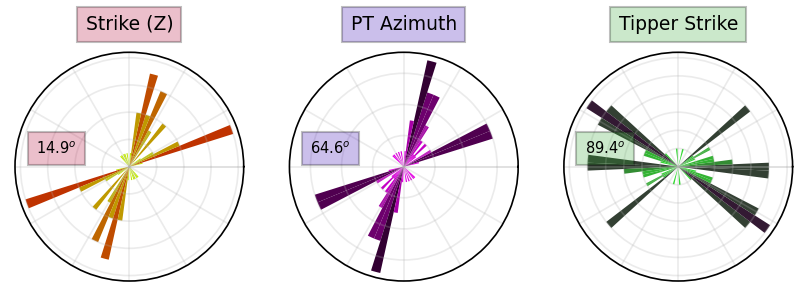

In [17]:
strike_plot = mtd.plot_strike()

### Strike geoeléctrico por periodos

Strike statistics for invariant period range 0.001 to 0.01 (s) median=66.1 mode=64.6 mean=111.7
Strike statistics for pt period range 0.001 to 0.01 (s) median=65.6 mode=64.6 mean=111.2
Strike statistics for tipper period range 0.001 to 0.01 (s) median=47.1 mode=44.7 mean=48.2
Strike statistics for invariant period range 0.01 to 0.1 (s) median=63.8 mode=64.6 mean=53.5
Strike statistics for pt period range 0.01 to 0.1 (s) median=63.1 mode=64.6 mean=53.1
Strike statistics for tipper period range 0.01 to 0.1 (s) median=81.6 mode=89.4 mean=80.9
Strike statistics for invariant period range 0.1 to 1 (s) median=15.1 mode=14.9 mean=15.4
Strike statistics for pt period range 0.1 to 1 (s) median=15.9 mode=14.9 mean=15.6
Strike statistics for tipper period range 0.1 to 1 (s) median=115.5 mode=114.2 mean=110.8
Strike statistics for invariant period range 1 to 10 (s) median=31.4 mode=9.9 mean=109.1
Strike statistics for pt period range 1 to 10 (s) median=32.1 mode=9.9 mean=108.4
Strike statistics fo

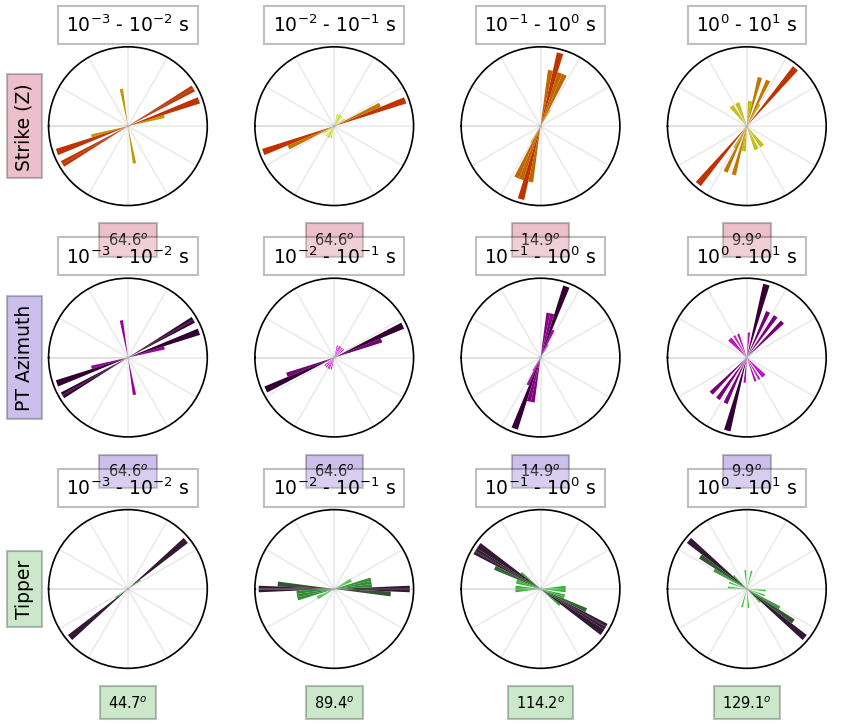

In [18]:
trike_plot_per_decade = mtd.plot_strike(plot_type=1, print_stats=True)

Strike statistics for invariant period range 0.001 to 0.01 (s) median=66.1 mode=64.6 mean=111.7
Strike statistics for pt period range 0.001 to 0.01 (s) median=65.6 mode=64.6 mean=111.2
Strike statistics for tipper period range 0.001 to 0.01 (s) median=47.1 mode=44.7 mean=48.2
Strike statistics for invariant period range 0.01 to 0.1 (s) median=63.8 mode=64.6 mean=53.5
Strike statistics for pt period range 0.01 to 0.1 (s) median=63.1 mode=64.6 mean=53.1
Strike statistics for tipper period range 0.01 to 0.1 (s) median=81.6 mode=89.4 mean=80.9
Strike statistics for invariant period range 0.1 to 1 (s) median=15.1 mode=14.9 mean=15.4
Strike statistics for pt period range 0.1 to 1 (s) median=15.9 mode=14.9 mean=15.6
Strike statistics for tipper period range 0.1 to 1 (s) median=115.5 mode=114.2 mean=110.8
Strike statistics for invariant period range 1 to 10 (s) median=31.4 mode=9.9 mean=109.1
Strike statistics for pt period range 1 to 10 (s) median=32.1 mode=9.9 mean=108.4
Strike statistics fo

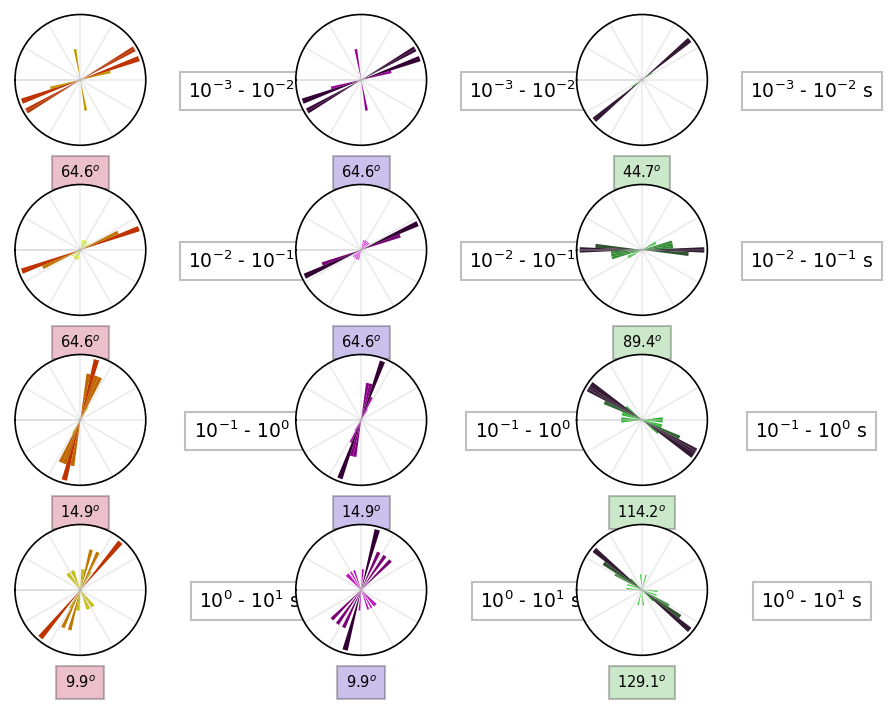

In [19]:
trike_plot_per_decade.plot_orientation = "vertical"
trike_plot_per_decade.redraw_plot()